***.loc*** ==> Used in places where we use labels to access rows and columns from either a dataframe or a table.

***.iloc*** ==> Used in places where we use indexes to access rows and columns from either a dataframe or a table.

***apply()*** ==> Used when there is need of conditional cases to be performed on column.
These are usually slow as they are applied row wise(one-by-one)

***vectorized*** ==> Used when there is a need for instant math application on columns, this is faster as it handles operations using Single instruction Multipe data principle making it to be applied simultaneously.


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(f"Shape: " + str(df.shape))

df = pd.DataFrame(df)

Shape: (891, 12)
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 .

In [10]:
for col in df.columns:
  print(f"{col} : {df[col].dtypes}")

PassengerId : int64
Survived : int64
Pclass : int64
Name : object
Sex : object
Age : float64
SibSp : int64
Parch : int64
Ticket : object
Fare : float64
Cabin : object
Embarked : object


In [16]:
for col in df.columns:
  print(f"{col} :==> {df[col].isna().sum()}")

PassengerId :==> 0
Survived :==> 0
Pclass :==> 0
Name :==> 0
Sex :==> 0
Age :==> 177
SibSp :==> 0
Parch :==> 0
Ticket :==> 0
Fare :==> 0
Cabin :==> 687
Embarked :==> 2


In [21]:
for col in df.columns:
  print(f"{col} :==> {df[col].nunique()}")

PassengerId :==> 891
Survived :==> 2
Pclass :==> 3
Name :==> 891
Sex :==> 2
Age :==> 88
SibSp :==> 7
Parch :==> 7
Ticket :==> 681
Fare :==> 248
Cabin :==> 147
Embarked :==> 3


In [30]:
survived = df['Survived'].mean()
survived_gender = df.groupby('Sex')["Survived"].mean()
survived_class = df.groupby('Pclass')["Survived"].mean()
survived_age_mean = df.groupby('Survived')["Age"].mean()
survived_embarked_max = df.groupby('Embarked')["Survived"].mean().idxmax()

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100], labels=["Child", "Teen", "Adult", "Elder"])
survived_age_max = df.groupby('AgeGroup', observed= False)['Survived'].mean().idxmax()

print(f"Survival rate overall : {survived}")
print(f"Survival rate by gender : {survived_gender}")
print(f"Survival rate by passenger class : {survived_class}")
print(f"Average age of survivors vs non-survivors : {survived_age_mean}")
print(f"Survival rate by passenger class : {survived_embarked_max}")
print(f"Age group with highest survival rate : {survived_age_max}")


Survival rate overall : 0.3838383838383838
Survival rate by gender : Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival rate by passenger class : Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Average age of survivors vs non-survivors : Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64
Survival rate by passenger class : C
Age group with highest survival rate : Child


In [28]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Family"] = pd.cut(df["FamilySize"], bins=[0, 1, 4, 10], labels=["Alone", "Small Family", "Large Family"])
survived_family = df.groupby("Family")["Survived"].mean()
print(f"Survival rate by family size : {survived_family}")

Survival rate by family size : Family
Alone           0.303538
Small Family    0.578767
Large Family    0.181818
Name: Survived, dtype: float64


/tmp/ipykernel_4064/440170622.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_family = df.groupby("Family")["Survived"].mean()


/tmp/ipykernel_4064/3711536727.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_family = df.groupby("Family")["Survived"].sum()


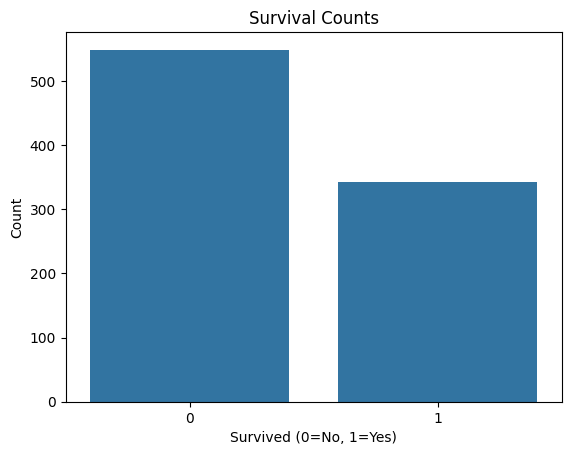


Death count is more than the survival count



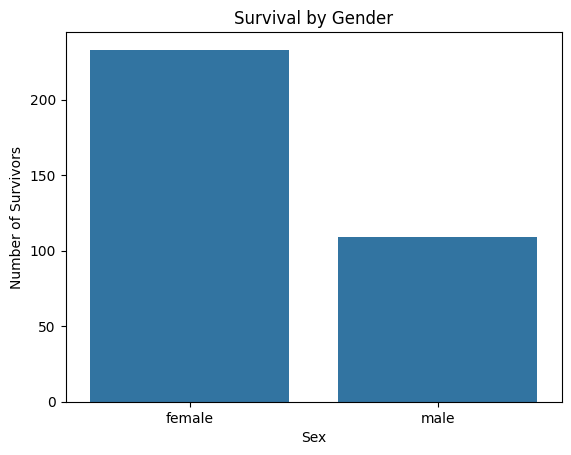


Females are more likely to have survived than men



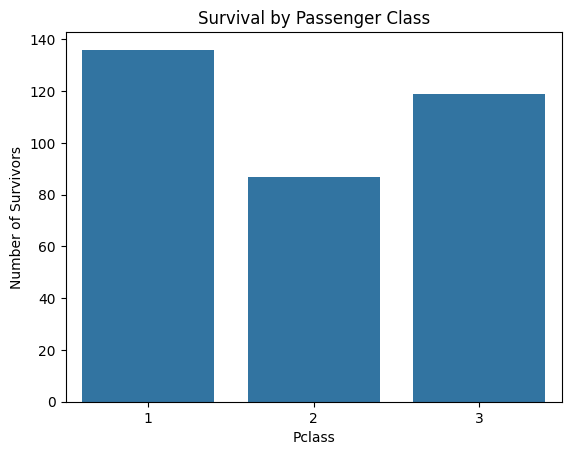


High Class Passenger has seen to have a slightly higher survival rate than Low Class Passengers 



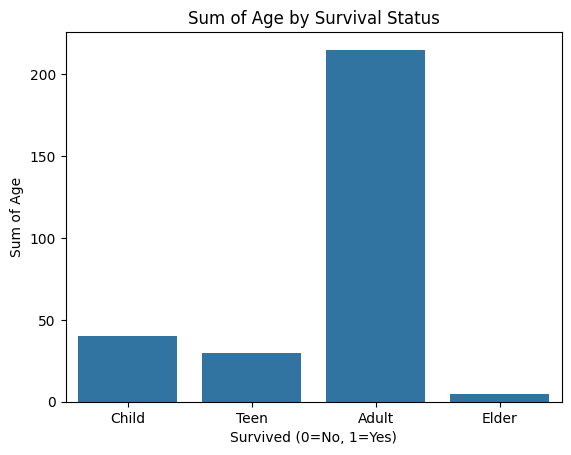


Observed high survivability of Adult (18-60) passengers Though this may be due to class imbalance 



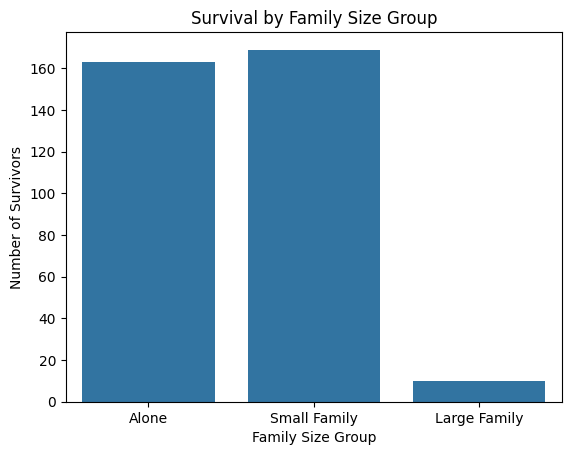


Both Passenger groups who came alone and as a small family have managed to survive the crash


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


# Corrected: Use value_counts to get counts of each survival status for plotting
survived_counts = df['Survived'].value_counts()
survived_gender = df.groupby('Sex')["Survived"].sum()
survived_class = df.groupby('Pclass')["Survived"].sum()
survived_age_max = df.groupby('AgeGroup', observed= False)['Survived'].sum()
survived_family = df.groupby("Family")["Survived"].sum()

# Corrected: Plotting survived_counts as a bar plot
sns.barplot(x=survived_counts.index, y=survived_counts.values).set(title='Survival Counts', xlabel='Survived (0=No, 1=Yes)', ylabel='Count')
plt.show()
print("\nDeath count is more than the survival count\n")

sns.barplot(survived_gender).set(title='Survival by Gender', xlabel='Sex', ylabel='Number of Survivors')
plt.show()
print("\nFemales are more likely to have survived than men\n")

sns.barplot(survived_class).set(title='Survival by Passenger Class', xlabel='Pclass', ylabel='Number of Survivors')
plt.show()
print("\nHigh Class Passenger has seen to have a slightly higher survival rate than Low Class Passengers \n")

sns.barplot(survived_age_max).set(title='Sum of Age by Survival Status', xlabel='Survived (0=No, 1=Yes)', ylabel='Sum of Age')
plt.show()
print("\nObserved high survivability of Adult (18-60) passengers Though this may be due to class imbalance \n")

sns.barplot(survived_family).set(title='Survival by Family Size Group', xlabel='Family Size Group', ylabel='Number of Survivors')
plt.show()
print("\nBoth Passenger groups who came alone and as a small family have managed to survive the crash")

# Q1

***Why is EDA important before training a model?***

EDA which encompasses processess like data cleaning, finding missing values or filling them, plotting them to recognize patterns make analysts get a better idea about what the dataset provides as a fact,
and if used in real cases this kind of analysis provides better insights about public interests for public dataset or any other cases.

# Q2

***What problems can missing values cause?***

Missing values can cause runtime time error when performing vectorized operations as well as apply type operations. And it also causes plotting problems unless handled correclty.
In real world scenario, missing values can cause misconception in understanding user preferences.

# Q3

***Why can feature engineering improve performance?***

Feature engineering provides new ways to get insights from existing data, improving performace rapidly by providing suitable methods to make use of existing data to be handled.

# Q4

***Why is class imbalance dangerous?***

Class Imbalance causes misconception or bias in insights provided during analysis which may cause tremendous loss to a company that relies on this type of analysis, all the same goes for when using it to train models, which causes the model to inherently lean towards the majority class.

# Q5

***Suppose Titanic survival prediction performs poorly. What would you investigate first?***

* Check for class imbalance
* Perform EDA
* Cross Validation Results
* Presence of overfitting / underfitting
